# DESI DR1 ELG vs GALFORM mock with SCOPE

Goal: build a GALFORM ELG-like mock from /cosma5/data/durham/dc-hick2/Galform_Out/L800/lc16, estimate xi(r) with SCOPE using 8 subvolumes, and compare to DESI DR1 ELG.

Notes:
- Available snapshots at this path are iz155, iz207, iz271 only. iz155 (z ~ 1.5) is used for 1.1-1.6; iz207 (z ~ 0.5) is the closest available for 0.8-1.1.
- The ELG selection below is a best-effort cut on stellar mass and sSFR. Adjust thresholds if you want a different number density or color selection.

In [9]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

def find_repo_root(start=None):
    if start is None: start = Path.cwd()
    for c in [start, *start.parents]:
        if (c / 'pyproject.toml').exists() and (c / 'src').exists():
            return c
    raise FileNotFoundError('repo root not found')

repo = find_repo_root()
if str(repo / 'src') not in sys.path:
    sys.path.insert(0, str(repo / 'src'))

SCOPE_PY = Path('/cosma/apps/durham/dc-hick2/SCOPE/python')
if str(SCOPE_PY) not in sys.path:
    sys.path.insert(0, str(SCOPE_PY))

from scope import compute_xi
from galform_analysis.config import get_snapshot_redshift, N_SUBVOLUMES
from galform_analysis.utils.read_galaxies import read_galaxy_arrays
from galform_analysis.io.loaders import read_snapshot_data
try:
    from galform_analysis.utils.matplotlib_config import setconfig
    setconfig()
except ImportError:
    pass

plt.close('all')
mpl.rcdefaults()


## 1  Load DESI DR1 xi(r)

In [10]:
N_RAN = 4   # match n-ran used in compute job

desi_dir = repo / 'data' / 'desi' / 'csvs'
desi_bins = {'0.8-1.1': (0.8, 1.1), '1.1-1.6': (1.1, 1.6)}

desi_xi = {}
for label, (z_min, z_max) in desi_bins.items():
    fn = desi_dir / f'desi_elg_dr1_xi_z{z_min:.1f}_{z_max:.1f}_nran{N_RAN}.csv'
    if fn.exists():
        desi_xi[label] = pd.read_csv(fn)
        print(f'Loaded DR1 {label}: {fn.name}')
    else:
        print(f'NOT FOUND - submit compute job first: {fn}')

# 1% survey pycorr pair-count files (reference)
old_path = repo / 'data' / 'desi'
catalog  = 'ELG_NScomb'
wt_str   = 'default_bitwise_angular_FKP'

def load_pycorr_xi(zlim_str):
    fn = old_path / f'allcounts_{catalog}_{zlim_str}_{wt_str}_log_njack128_nran18_split20.npy'
    if not fn.exists():
        return None
    d = np.load(fn, allow_pickle=True).item()
    def nw(c): return c['wcounts'] / c['wnorm']
    dd, dr, rd, rr = nw(d['D1D2']), nw(d['D1R2']), nw(d['R1D2']), nw(d['R1R2'])
    xi_smu = np.where(rr > 0, (dd - dr - rd + rr) / rr, np.nan)
    s_e = d['D1D2']['edges'][0]
    s_c = 0.5 * (s_e[:-1] + s_e[1:])
    xi_r = np.nanmean(xi_smu, axis=1)
    return pd.DataFrame({'s': s_c, 'xi0': xi_r})

desi_1pct = {}
for zlim_str, label in [('0.8_1.1', '0.8-1.1'), ('1.1_1.6', '1.1-1.6')]:
    df = load_pycorr_xi(zlim_str)
    if df is not None:
        desi_1pct[label] = df
        print(f'Loaded 1% survey {label}')
    else:
        print(f'1% survey {label}: not found')


Loaded DR1 0.8-1.1: desi_elg_dr1_xi_z0.8_1.1_nran4.csv
Loaded DR1 1.1-1.6: desi_elg_dr1_xi_z1.1_1.6_nran4.csv


/tmp/ipykernel_2945200/88738067.py:30: RuntimeWarning: Mean of empty slice
  xi_r = np.nanmean(xi_smu, axis=1)


Loaded 1% survey 0.8-1.1
Loaded 1% survey 1.1-1.6


## 2  Configure snapshots and ELG-like selection

In [11]:
base_dir = Path('/cosma5/data/durham/dc-hick2/Galform_Out/L800/lc16')
box_size = 542.16
k_total = int(N_SUBVOLUMES)

# Use the closest available snapshots to DESI DR1 bins
snapshots = {
    '0.8-1.1': 207,  # z ~ 0.5 (closest available)
    '1.1-1.6': 155,  # z ~ 1.5
}

for label, iz in snapshots.items():
    z = get_snapshot_redshift(f'iz{iz}')
    print(f'{label}: iz{iz} -> z ~ {z}')

# SCOPE configuration
N_SUBVOLS = 8
SEED = 1000
R_MIN = 0.1
R_MAX = 50.0
N_R_BINS = 20

# ELG-like selection (best effort - tune as needed)
MSTAR_MIN_LOG10 = 9.5
MSTAR_MAX_LOG10 = 11.2
SSFR_MIN_LOG10 = -10.5
CENTRALS_ONLY = False

# Optional color cut if SDSS g/r band luminosities are present
USE_GR_COLOR = True
GR_MAX = 0.7

# Optional throttles for runtime
SAMPLE_FRACTION = 1.0
MAX_GAL_PER_IVOL = None


0.8-1.1: iz207 -> z ~ 0.495942
1.1-1.6: iz155 -> z ~ 1.49551


## 3  Build mock catalog and run SCOPE xi(r)

In [12]:
def discover_ivols(iz_path):
    iz_dir = Path(iz_path)
    ivols = sorted(
        int(p.name.replace('ivol', ''))
        for p in iz_dir.glob('ivol*')
        if p.is_dir() and p.name.replace('ivol', '').isdigit()
    )
    if not ivols:
        raise RuntimeError(f'No ivol directories under {iz_dir}')
    return ivols


def load_band_lums(iz_path, ivol):
    snap = read_snapshot_data(iz_path, ivol=ivol)
    f = snap.pop('file')
    try:
        Lg = snap.get('Lg')
        Lr = snap.get('Lr')
    finally:
        try:
            f.close()
        except Exception:
            pass
    if Lg is None or Lr is None:
        return None
    if len(Lg) == 0 or len(Lr) == 0:
        return None
    return np.asarray(Lg), np.asarray(Lr)


def load_ivol_catalog(iz_path, ivol, rank):
    arrays, _ = read_galaxy_arrays(
        iz_path,
        ivol=int(ivol),
        include_positions=True,
        include_derived=True,
        centrals_only=CENTRALS_ONLY,
        mhalo_min=None,
    )

    n = len(arrays['x'])
    if n == 0:
        return None, None

    mstar = arrays.get('mstar')
    sfr = arrays.get('sfr')
    mask = np.ones(n, dtype=bool)

    if mstar is not None:
        if MSTAR_MIN_LOG10 is not None:
            mask &= mstar >= 10.0 ** MSTAR_MIN_LOG10
        if MSTAR_MAX_LOG10 is not None:
            mask &= mstar <= 10.0 ** MSTAR_MAX_LOG10

    if sfr is not None and mstar is not None:
        ssfr = np.full(n, np.nan, dtype=float)
        ok = (mstar > 0) & np.isfinite(mstar) & np.isfinite(sfr)
        ssfr[ok] = sfr[ok] / mstar[ok]
        if SSFR_MIN_LOG10 is not None:
            mask &= np.isfinite(ssfr) & (ssfr > 0) & (np.log10(ssfr) >= SSFR_MIN_LOG10)

    if USE_GR_COLOR:
        lums = load_band_lums(iz_path, ivol)
        if lums is not None and len(lums[0]) == n:
            Lg, Lr = lums
            color = -2.5 * np.log10(Lg / Lr)
            mask &= np.isfinite(color) & (color <= GR_MAX)
        else:
            print('  warning: g/r band data not available - skipping color cut')

    if SAMPLE_FRACTION < 1.0:
        rng = np.random.default_rng(SEED + int(ivol))
        mask &= rng.random(n) < SAMPLE_FRACTION

    if MAX_GAL_PER_IVOL is not None:
        idx = np.where(mask)[0]
        if len(idx) > MAX_GAL_PER_IVOL:
            rng = np.random.default_rng(SEED + int(ivol))
            keep = rng.choice(idx, size=MAX_GAL_PER_IVOL, replace=False)
            new_mask = np.zeros(n, dtype=bool)
            new_mask[keep] = True
            mask = new_mask

    if mask.sum() == 0:
        return None, None

    pos = np.column_stack(
        [arrays['x'][mask], arrays['y'][mask], arrays['z'][mask]]
    ).astype(np.float64)
    svid = np.full(len(pos), rank, dtype=np.int32)
    return pos, svid


def build_scope_inputs(iz, n_subvols_selected, seed):
    iz_path = str(base_dir / f'iz{iz}')
    ivols = discover_ivols(iz_path)
    rng = np.random.default_rng(seed)
    perm = rng.permutation(ivols)
    chosen = perm[:n_subvols_selected].tolist()

    pos_list = []
    svid_list = []
    for rank, ivol in enumerate(chosen):
        pos, svid = load_ivol_catalog(iz_path, ivol, rank)
        if pos is None:
            continue
        pos_list.append(pos)
        svid_list.append(svid)

    if not pos_list:
        raise RuntimeError('No galaxies loaded - check selection or paths')

    coords = np.vstack(pos_list).astype(np.float64)
    svids = np.concatenate(svid_list).astype(np.int32)
    return coords, svids, chosen


def compute_scope_xi_for_snapshot(iz):
    r_bins = np.logspace(np.log10(R_MIN), np.log10(R_MAX), N_R_BINS + 1)
    r_mid = np.sqrt(r_bins[:-1] * r_bins[1:])

    coords, svids, chosen = build_scope_inputs(iz, N_SUBVOLS, SEED)
    print(f'iz{iz}: loaded {len(coords):,} galaxies from {len(chosen)} realisations')

    res = compute_xi(
        coords=coords,
        subvol_ids=svids,
        r_bins=r_bins,
        box_size=box_size,
        n_subvols=k_total,
        n_subvols_selected=N_SUBVOLS,
    )

    df = pd.DataFrame({
        'r': r_mid,
        'xi': res['xi'],
        'dd_auto': res['dd_auto'],
        'dd_cross': res['dd_cross'],
        'dd_corr': res['dd_corr'],
        'rr': res['rr'],
        'ngal': len(coords),
    })
    return df


In [13]:
scope_xi = {}
for label, iz in snapshots.items():
    scope_xi[label] = compute_scope_xi_for_snapshot(iz)
    print(f'Computed SCOPE xi for {label} (iz{iz})')


iz207: loaded 14,389 galaxies from 8 realisations
Computed SCOPE xi for 0.8-1.1 (iz207)
iz155: loaded 11,187 galaxies from 8 realisations
Computed SCOPE xi for 1.1-1.6 (iz155)


## 4  Plot: DESI DR1 vs GALFORM mock (SCOPE, n=8)

In [16]:

from galform_analysis.utils.matplotlib_config import setconfig
setconfig()

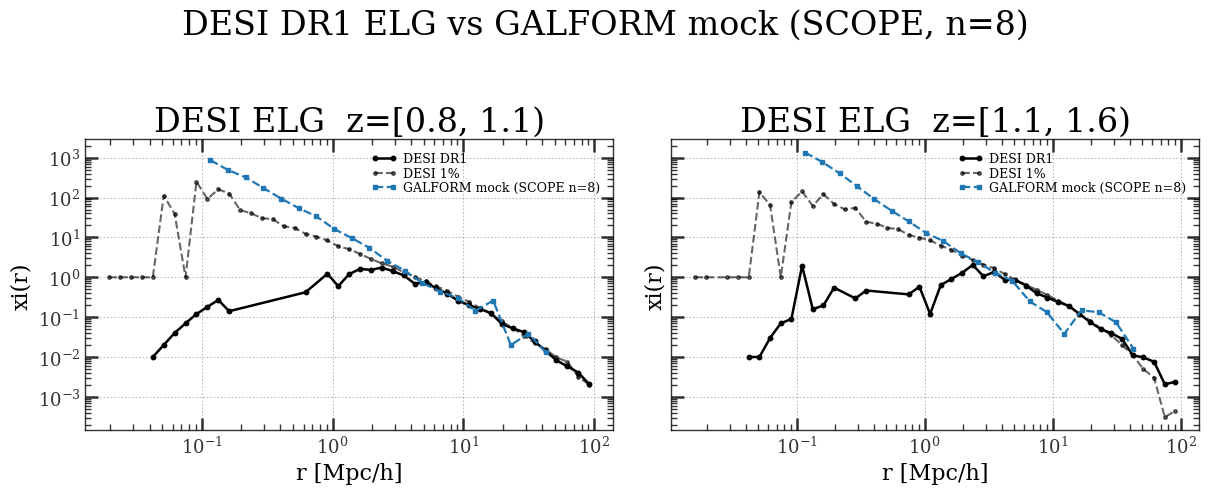

In [ ]:
colors = {'0.8-1.1': 'black', '1.1-1.6': '#d04f2f'}
zlabels = {'0.8-1.1': 'z=[0.8, 1.1)', '1.1-1.6': 'z=[1.1, 1.6)'}

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0), sharey=True)

for ax, label in zip(axes, ['0.8-1.1', '1.1-1.6']):
    # DESI DR1
    if label in desi_xi:
        df = desi_xi[label]
        m = np.isfinite(df['xi0']) & (df['xi0'] > 0) & (df['s'] > 0)
        ax.loglog(df['s'][m], df['xi0'][m],
                  lw=1.8, marker='o', markersize=3.2,
                  color='black', label='DESI DR1')

    if 1==0:
        # 1% survey
        if label in desi_1pct:
            df = desi_1pct[label]
            m = np.isfinite(df['xi0']) & (df['xi0'] > 0) & (df['s'] > 0)
            ax.loglog(df['s'][m], df['xi0'][m],
                    lw=1.5, ls='--', marker='o', markersize=2.5, alpha=0.6,
                    color='black', label='DESI 1%')

    # GALFORM mock (SCOPE n=8)
    if label in scope_xi:
        df = scope_xi[label]
        m = np.isfinite(df['xi']) & (df['xi'] > 0) & (df['r'] > 0)
        ax.loglog(df['r'][m], df['xi'][m],
                  lw=1.6, ls='--', marker='s', markersize=3.0,
                  color='#1f77b4', label='GALFORM mock (SCOPE n=8)')

    ax.set_xlim(1e-1, 100)
    ax.set_xlabel('r [Mpc/h]')
    ax.set_ylabel('xi(r)')
    ax.set_title(f'DESI ELG  {zlabels[label]}')
    #ax.grid(True, which='both', alpha=0.25)
    ax.legend(fontsize=9)

fig.suptitle('DESI DR1 ELG vs GALFORM mock (SCOPE, n=8)', y=1.01)
fig.tight_layout()
plot_dir = repo / '_plots'
plot_dir.mkdir(exist_ok=True)
fig.savefig(plot_dir / 'desi_dr1_vs_galform_scope_mock.pdf', bbox_inches='tight')
fig.savefig(plot_dir / 'desi_dr1_vs_galform_scope_mock.png', dpi=150, bbox_inches='tight')
plt.show()


## 5  Optional: save SCOPE outputs

In [15]:
out_dir = repo / 'data' / 'desi' / 'galform_scope_mock'
out_dir.mkdir(parents=True, exist_ok=True)
for label, df in scope_xi.items():
    iz = snapshots[label]
    fn = out_dir / f'galform_scope_mock_xi_iz{iz}_n{N_SUBVOLS}.csv'
    df.to_csv(fn, index=False)
    print(f'Saved {fn}')


Saved /cosma/apps/durham/dc-hick2/galform_analysis/data/desi/galform_scope_mock/galform_scope_mock_xi_iz207_n8.csv
Saved /cosma/apps/durham/dc-hick2/galform_analysis/data/desi/galform_scope_mock/galform_scope_mock_xi_iz155_n8.csv
